## Text Classification project
Project Objective: Build a text classification model that predicts the intent of customer review whether the review is positive or negative.
## Data Gathering

In [341]:
path=r'https://raw.githubusercontent.com/sindhura-nk/Datasets/refs/heads/main/Restaurant_Reviews.tsv'
import pandas as pd
df=pd.read_csv(path,sep='\t')
df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


Liked = 1 : Positive review

Not Liked = 0 : Negative review

In [342]:
df['Review'].head(10)

0                             Wow... Loved this place.
1                                   Crust is not good.
2            Not tasty and the texture was just nasty.
3    Stopped by during the late May bank holiday of...
4    The selection on the menu was great and so wer...
5       Now I am getting angry and I want my damn pho.
6                Honeslty it didn't taste THAT fresh.)
7    The potatoes were like rubber and you could te...
8                            The fries were great too.
9                                       A great touch.
Name: Review, dtype: str

## Data preprocessing

In [343]:
df['Review'][0]

'Wow... Loved this place.'

In [344]:
s1=df['Review'][0]
s1.lower()

'wow... loved this place.'

In [345]:
import re
s1=s1.lower()
pattern =r"[^a-z ]"
s1=re.sub(pattern,"",s1)
s1

'wow loved this place'

In [346]:
def preprocess(text):
  text=text.lower()
  pattern = r"[^a-z ]"
  text=re.sub(pattern,"",text)
  return text

In [347]:
df['Review_Preprocessed']=df['Review'].apply(preprocess)

In [348]:
df['Review_Preprocessed'].head(10)

0                                 wow loved this place
1                                    crust is not good
2             not tasty and the texture was just nasty
3    stopped by during the late may bank holiday of...
4    the selection on the menu was great and so wer...
5        now i am getting angry and i want my damn pho
6                   honeslty it didnt taste that fresh
7    the potatoes were like rubber and you could te...
8                             the fries were great too
9                                        a great touch
Name: Review_Preprocessed, dtype: str

In [349]:
df.head()

,Review,Liked,Review_Preprocessed
0,Wow... Loved this place.,1,wow loved this place
1,Crust is not good.,0,crust is not good
2,Not tasty and the texture was just nasty.,0,not tasty and the texture was just nasty
3,Stopped by during the late May bank holiday of...,1,stopped by during the late may bank holiday of...
4,The selection on the menu was great and so wer...,1,the selection on the menu was great and so wer...


## Separate X and Y features
X: Review_Preprocessed

Y : Liked

In [350]:
x=df['Review_Preprocessed']
y=df['Liked']

In [351]:
x[:10]

0                                 wow loved this place
1                                    crust is not good
2             not tasty and the texture was just nasty
3    stopped by during the late may bank holiday of...
4    the selection on the menu was great and so wer...
5        now i am getting angry and i want my damn pho
6                   honeslty it didnt taste that fresh
7    the potatoes were like rubber and you could te...
8                             the fries were great too
9                                        a great touch
Name: Review_Preprocessed, dtype: str

## Vectorization

In [352]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf =TfidfVectorizer()
xpre =tfidf.fit_transform(x).toarray()

In [353]:
xpre[:10]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(10, 2046))

## Split the data into training and testing

In [354]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(xpre,y,train_size=0.85,random_state=21)

In [355]:
# ✅ Step 1 — Check what your data looks like BEFORE cleaning
print(xtrain[:5])
print(type(xtrain[0]))


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
<class 'numpy.ndarray'>


In [356]:
import re
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

class TextCleaner(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        return self  # ✅ Required — must return self
    
    def transform(self, X):
        return [self._clean(text) for text in X]  # ✅ Apply to each row
    
    def _clean(self, text):
        text = text.lower()
        pattern = r"[^a-z ]"
        text = re.sub(pattern, "", text)
        return text


class TextTransformer(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        self.tfidf = TfidfVectorizer()
        self.tfidf.fit(X)  # ✅ Fit ONLY during fit(), not transform()
        return self
    
    def transform(self, X):
        return self.tfidf.transform(X).toarray()  # ✅ Use saved tfidf, not fit again


# Build pipeline
preprocessing_pipeline = Pipeline([
    ('cleaner',     TextCleaner()),
    ('transformer', TextTransformer())
])

# ✅ Fit ONLY on training data
preprocessing_pipeline.fit(x)



# Save pipeline
joblib.dump(preprocessing_pipeline, "text_classification_pre.joblib")

['text_classification_pre.joblib']

## Model Building
While building and tuning the model, you can tweak below parameters and see if there is significant change in the model predictions. **Awalys restart kernel and run all cells**


1.  while splitting the data into training and testing, you can modify the size

2.   you can increase more neurons to the hidden layers

3.   you can add more layers to the architechture

4.  you can update the patience levels in ReduceLR

5. you can update the batch size




In [357]:
from keras.models import Sequential
from keras.layers import Input,Dense,Dropout
from keras.callbacks import ReduceLROnPlateau

# Intialize the model
model = Sequential()

# Add the layers
model.add(Input(shape=(xtrain.shape[1],)))

# Add the hidden layer
model.add(Dense(units=64,activation='relu'))
model.add(Dropout(rate=0.3))

# Add the hidden layer
model.add(Dense(units=32,activation='relu'))
model.add(Dropout(rate=0.2))

# Add the hidden layer
model.add(Dense(units=16,activation='relu'))
model.add(Dropout(rate=0.1))

# Add the Output layer
model.add(Dense(units=1,activation='sigmoid'))

In [358]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
learning_rate = ReduceLROnPlateau(monitor='val_loss',patience=2,min_lr=0.0001,factor=0.85,verbose=1)

In [359]:
nn=model.fit(xtrain,ytrain,validation_split=0.2,epochs=15,callbacks=[learning_rate],batch_size=8)

Epoch 1/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5485 - loss: 0.6914 - val_accuracy: 0.5647 - val_loss: 0.6885 - learning_rate: 0.0010
Epoch 2/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7206 - loss: 0.6575 - val_accuracy: 0.6882 - val_loss: 0.6243 - learning_rate: 0.0010
Epoch 3/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8971 - loss: 0.4134 - val_accuracy: 0.7824 - val_loss: 0.4602 - learning_rate: 0.0010
Epoch 4/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9618 - loss: 0.1466 - val_accuracy: 0.7882 - val_loss: 0.4452 - learning_rate: 0.0010
Epoch 5/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9794 - loss: 0.0632 - val_accuracy: 0.7647 - val_loss: 0.5320 - learning_rate: 0.0010
Epoch 6/15
76/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9960 - loss: 0.0293
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0008500000403728336.
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9941 - loss: 0.0283 - val_accuracy: 0

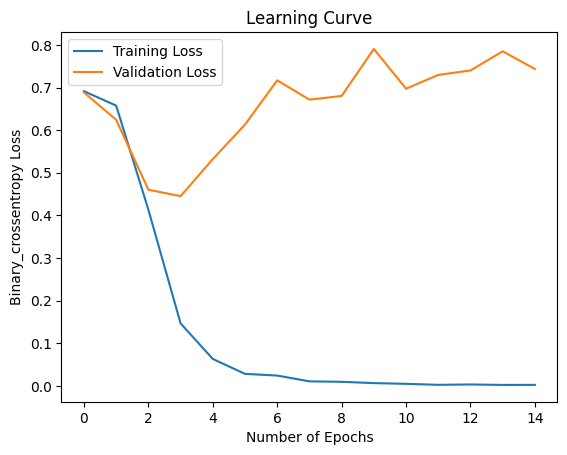

In [360]:


import matplotlib.pyplot as plt
plt.plot(nn.history['loss'],label='Training Loss')
plt.plot(nn.history['val_loss'],label='Validation Loss')
plt.title("Learning Curve")
plt.xlabel("Number of Epochs")
plt.ylabel("Binary_crossentropy Loss")
plt.legend()
plt.show()

In [361]:
model.evaluate(xtrain,ytrain)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9612 - loss: 0.1490   


[0.14895333349704742, 0.9611764550209045]

In [362]:
model.evaluate(xtest,ytest)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8533 - loss: 0.5239 


[0.5239023566246033, 0.8533333539962769]

## Accuracy score is 80% . We can consider this model as final model

In [363]:
import joblib
joblib.dump(model,"TextClassificaitonModel.joblib")

['TextClassificaitonModel.joblib']

In [364]:


model.save("TextClassification.keras")

## Out of sample predictions

In [365]:
review = "Food tasted great. WIll visit agAIN..!!"

In [366]:
review_updated = preprocess(review)
review_updated

'food tasted great will visit again'

In [367]:
review_updated_pre = tfidf.transform([review_updated]).toarray()
review_updated_pre

array([[0., 0., 0., ..., 0., 0., 0.]], shape=(1, 2046))

In [368]:


probs = model.predict(review_updated_pre,verbose=0)

probs

array([[0.99998105]], dtype=float32)

In [369]:
if probs>0.5:
  print("Positive Review")
else:
  print("Negative Review")

Positive Review


In [370]:

def predict(text):
  review_updated = preprocess(text)
  review_pre = tfidf.transform([review_updated]).toarray()
  probs = model.predict(review_pre,verbose=0)
  if probs>0.5:
    print("Positive Review")
  else:
    print("Negative Review")

In [371]:


predict(review)

Positive Review
